# Modelo Causal v7 — IPTW Corrigido (v2)

**Objetivo 4 do TCC:*Avaliar a robustez das estimativas causais por meio da comparação entre diferentes especificações do modelo de propensity score e do cálculo do E-value para quantificar a sensibilidade a confundidores não observados. *****AINDA NAO FINALIZEI 

Corrige os dois problemas identificados no v6:

## Problemas do v6 e correcoes aplicadas

### Problema 1 — `frete_alto`: propensity score instavel
| Item | v6 | v7 |
|---|---|---|
| Modelo PS | Regressao Logistica | **HistGradientBoosting** (~10x mais rapido que GBM) |
| Confundidores | `total_price` incluido | **`total_price` removido** (colinear: frete = freight/price) |
| Pesos | max=55.4 (instavel) | trimming aplicado (percentil 99) |
| Bootstrap | 500x com GBM | **200x com logistic** (ATE pontual usa hgbm) |

### Problema 2 — `pedido_grande`: confundidor = base do tratamento
| Item | v6 | v7 |
|---|---|---|
| `n_items` nos confundidores | incluido (errado) | **Removido** (`pedido_grande = n_items > 1`) |
| SMD de `n_items` | 1.93 antes e depois | Nao se aplica — variavel removida |

## Analises neste notebook
- `frete_alto -> entrega_atrasada`
- `frete_alto -> review_positivo`
- `pedido_grande -> entrega_atrasada`
- `pedido_grande -> review_positivo`

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

from app.config.settings import INTERIM_DATA_DIR

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Carregamento e preparacao dos dados

In [2]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["approval_time_hours"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

df["dispatch_time_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
).dt.days

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["perc_freight"] = df["total_freight"] / df["total_price"]

# Tratamentos
df["frete_alto"]    = (df["perc_freight"] > 0.2).astype(int)
df["pedido_grande"] = (df["n_items"] > 1).astype(int)

# Outcomes
df["entrega_atrasada"] = (df["delay_days"] > 0).astype(int)
df["review_positivo"]  = (df["review_score"] >= 4).astype(int)

print(f"Shape: {df.shape}")

Shape: (97712, 44)


## 3. Confundidores corrigidos

### Para `frete_alto`
- **Removido**: `total_price` e `n_items` — `frete_alto = total_freight / total_price > 0.2`, colinearidade estrutural
- **Adicionado**: `avg_price` no lugar de `total_price`

### Para `pedido_grande`
- **Removido**: `n_items` — `pedido_grande = (n_items > 1)` e transformacao direta de `n_items`
- **Mantido**: `total_price` — confundidor independente

In [3]:
# frete_alto: sem total_price e sem n_items
CONF_FRETE = [
    "avg_price", "avg_weight",
    "customer_state", "purchase_month",
    "purchase_weekday", "purchase_hour", "n_items_missing_info"
]

# pedido_grande: sem n_items
CONF_PEDIDO = [
    "total_price", "avg_weight",
    "customer_state", "purchase_month",
    "purchase_weekday", "purchase_hour", "n_items_missing_info"
]

print("Confundidores frete_alto: ",  CONF_FRETE)
print("Confundidores pedido_grande:", CONF_PEDIDO)

Confundidores frete_alto:  ['avg_price', 'avg_weight', 'customer_state', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'n_items_missing_info']
Confundidores pedido_grande: ['total_price', 'avg_weight', 'customer_state', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'n_items_missing_info']


## 4. Funcoes IPTW

- `model='hgbm'` usa **HistGradientBoostingClassifier** para o ATE pontual
- Bootstrap usa sempre **logistic** (rapido, suficiente para IC)
- `n_bootstrap=200` (padrao) — suficiente para IC 95% estavel

In [4]:
def preprocess(df, treatment, outcome, confundidores):
    cols = confundidores + [treatment, outcome]
    df_out = df[cols].dropna().copy()
    le = LabelEncoder()
    df_out["customer_state"] = le.fit_transform(df_out["customer_state"])
    continuous_cols = [c for c in confundidores if c != "customer_state"]
    scaler = StandardScaler()
    df_out[continuous_cols] = scaler.fit_transform(df_out[continuous_cols])
    return df_out


def compute_iptw_weights(df_model, treatment, confundidores,
                         stabilized=True, model="logistic", trim_percentile=99):
    X = df_model[confundidores].values
    T = df_model[treatment].values

    if model == "hgbm":
        clf = HistGradientBoostingClassifier(
            max_iter=100, max_depth=4,
            learning_rate=0.05, random_state=42
        )
    else:
        clf = LogisticRegression(max_iter=1000, random_state=42)

    clf.fit(X, T)
    ps = clf.predict_proba(X)[:, 1]
    ps = np.clip(ps, 0.01, 0.99)
    auc = roc_auc_score(T, ps)

    p_treated = T.mean()
    weights = np.where(
        T == 1,
        (p_treated / ps) if stabilized else (1 / ps),
        ((1 - p_treated) / (1 - ps)) if stabilized else (1 / (1 - ps))
    )
    if trim_percentile is not None:
        weights = np.clip(weights, None, np.percentile(weights, trim_percentile))

    return ps, weights, auc


def compute_smd(df_model, treatment, confundidores, weights=None):
    smds = {}
    T = df_model[treatment].values
    for col in confundidores:
        x = df_model[col].values
        if weights is not None:
            mean1 = np.average(x[T == 1], weights=weights[T == 1])
            mean0 = np.average(x[T == 0], weights=weights[T == 0])
            var1  = np.average((x[T == 1] - mean1)**2, weights=weights[T == 1])
            var0  = np.average((x[T == 0] - mean0)**2, weights=weights[T == 0])
        else:
            mean1, var1 = x[T == 1].mean(), x[T == 1].var()
            mean0, var0 = x[T == 0].mean(), x[T == 0].var()
        pooled_std = np.sqrt((var1 + var0) / 2)
        smds[col] = abs(mean1 - mean0) / pooled_std if pooled_std > 0 else 0
    return pd.Series(smds)


def ate_iptw(df_model, treatment, outcome, weights):
    T = df_model[treatment].values
    Y = df_model[outcome].values
    return (
        np.average(Y[T == 1], weights=weights[T == 1]) -
        np.average(Y[T == 0], weights=weights[T == 0])
    )


def bootstrap_ci(df_model, treatment, outcome, confundidores,
                 n_bootstrap=200, alpha=0.05, trim_percentile=99):
    # Bootstrap sempre com logistic — rapido e suficiente para IC
    ates = []
    n = len(df_model)
    for _ in range(n_bootstrap):
        sample = df_model.sample(n=n, replace=True)
        _, w, _ = compute_iptw_weights(
            sample, treatment, confundidores,
            model="logistic", trim_percentile=trim_percentile
        )
        ates.append(ate_iptw(sample, treatment, outcome, w))
    lower = np.percentile(ates, 100 * alpha / 2)
    upper = np.percentile(ates, 100 * (1 - alpha / 2))
    return lower, upper, np.array(ates)

In [5]:
def run_iptw_analysis(df, treatment, outcome, confundidores,
                      model="logistic", trim_percentile=99,
                      ate_v6=None, assoc_bruta=None, n_bootstrap=200):
    print(f"{'='*60}")
    print(f"IPTW v7: {treatment} -> {outcome}  [PS: {model}]")
    print(f"{'='*60}")

    df_model = preprocess(df, treatment, outcome, confundidores)
    print(f"N apos dropna: {len(df_model):,}")

    ps, weights, auc = compute_iptw_weights(
        df_model, treatment, confundidores,
        model=model, trim_percentile=trim_percentile
    )
    print(f"\nAUC-ROC PS: {auc:.4f}")
    print(f"PS     — media: {ps.mean():.3f} | min: {ps.min():.3f} | max: {ps.max():.3f}")
    print(f"Pesos  — media: {weights.mean():.3f} | min: {weights.min():.3f} | max: {weights.max():.3f}")

    smd_antes  = compute_smd(df_model, treatment, confundidores)
    smd_depois = compute_smd(df_model, treatment, confundidores, weights=weights)
    df_smd = pd.DataFrame({
        "SMD antes":  smd_antes.round(4),
        "SMD depois": smd_depois.round(4),
        "Balanceado?": smd_depois.apply(lambda x: "OK" if x < 0.1 else "FAIL")
    })
    print("\n--- Balanco das covariaveis (SMD < 0.1 = OK) ---")
    print(df_smd.to_string())

    ate = ate_iptw(df_model, treatment, outcome, weights)
    print(f"\nATE (IPTW v7):    {ate:+.6f}")
    if ate_v6 is not None:
        print(f"ATE (IPTW v6):    {ate_v6:+.6f}  (diff: {ate - ate_v6:+.6f})")
    if assoc_bruta is not None:
        print(f"Assoc. bruta EDA: {assoc_bruta:+.6f}")

    print(f"Calculando IC via bootstrap ({n_bootstrap} amostras, logistic)...")
    lower, upper, boot_ates = bootstrap_ci(
        df_model, treatment, outcome, confundidores,
        n_bootstrap=n_bootstrap, trim_percentile=trim_percentile
    )
    print(f"IC 95%: [{lower:.6f}, {upper:.6f}]")
    significativo = (lower > 0 or upper < 0)
    print(f"Resultado: {'Significativo' if significativo else 'NAO significativo (IC contem zero)'}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(boot_ates, bins=40, color="steelblue", alpha=0.7, edgecolor="white")
    axes[0].axvline(ate,   color="red",    linewidth=2,   label=f"ATE={ate:.4f}")
    axes[0].axvline(lower, color="orange", linewidth=1.5, linestyle="--", label=f"IC inf={lower:.4f}")
    axes[0].axvline(upper, color="orange", linewidth=1.5, linestyle="--", label=f"IC sup={upper:.4f}")
    axes[0].axvline(0,     color="black",  linewidth=1,   linestyle=":")
    if ate_v6:
        axes[0].axvline(ate_v6, color="green", linewidth=1.5,
                        linestyle="-.", label=f"v6={ate_v6:.4f}")
    axes[0].set_title(f"Bootstrap ATE\n{treatment} -> {outcome} [{model}]")
    axes[0].set_xlabel("ATE estimado")
    axes[0].set_ylabel("Frequencia")
    axes[0].legend(fontsize=8)
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    xi = np.arange(len(confundidores))
    axes[1].barh(xi - 0.2, smd_antes.values,  0.4, label="Antes",  color="coral",     alpha=0.8)
    axes[1].barh(xi + 0.2, smd_depois.values, 0.4, label="Depois", color="steelblue", alpha=0.8)
    axes[1].axvline(0.1, color="red", linestyle="--", linewidth=1, label="Limite 0.1")
    axes[1].set_yticks(xi)
    axes[1].set_yticklabels(confundidores, fontsize=8)
    axes[1].set_xlabel("SMD")
    axes[1].set_title("Balanco das covariaveis")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"../../reports/figures/iptw_v7_{treatment}_{outcome}.png", dpi=150)
    plt.show()

    return {
        "treatment": treatment, "outcome": outcome,
        "model_ps": model, "N": len(df_model), "auc": auc,
        "assoc_bruta": assoc_bruta, "ate_v6": ate_v6,
        "ate": ate, "ic_lower": lower, "ic_upper": upper,
        "significativo": significativo
    }

## 5. frete_alto — corrigido

### 5.1 — Frete alto -> Entrega atrasada

IPTW v7: frete_alto -> entrega_atrasada  [PS: hgbm]
N apos dropna: 96,929

AUC-ROC PS: 0.9560
PS     — media: 0.553 | min: 0.012 | max: 0.990
Pesos  — media: 0.749 | min: 0.451 | max: 4.835

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
avg_price                0.8064      0.5291        FAIL
avg_weight               0.1634      0.0669          OK
customer_state           0.2546      0.1466        FAIL
purchase_month           0.0125      0.0190          OK
purchase_weekday         0.0118      0.0106          OK
purchase_hour            0.0187      0.0243          OK
n_items_missing_info     0.0114      0.0123          OK

ATE (IPTW v7):    +0.005422
ATE (IPTW v6):    +0.013537  (diff: -0.008115)
Assoc. bruta EDA: +0.003300
Calculando IC via bootstrap (200 amostras, logistic)...
IC 95%: [0.006905, 0.017247]
Resultado: Significativo


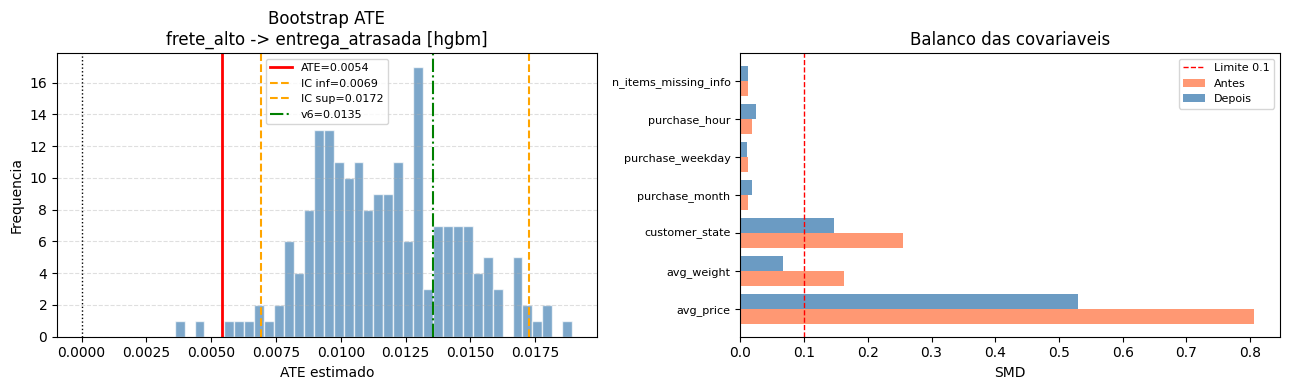

In [6]:
r1 = run_iptw_analysis(
    df, "frete_alto", "entrega_atrasada",
    confundidores=CONF_FRETE,
    model="hgbm",
    trim_percentile=99,
    n_bootstrap=200,
    ate_v6=0.013537,
    assoc_bruta=+0.0033
)

### 5.2 — Frete alto -> Review positivo

IPTW v7: frete_alto -> review_positivo  [PS: hgbm]
N apos dropna: 96,929

AUC-ROC PS: 0.9560
PS     — media: 0.553 | min: 0.012 | max: 0.990
Pesos  — media: 0.749 | min: 0.451 | max: 4.835

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
avg_price                0.8064      0.5291        FAIL
avg_weight               0.1634      0.0669          OK
customer_state           0.2546      0.1466        FAIL
purchase_month           0.0125      0.0190          OK
purchase_weekday         0.0118      0.0106          OK
purchase_hour            0.0187      0.0243          OK
n_items_missing_info     0.0114      0.0123          OK

ATE (IPTW v7):    -0.013410
ATE (IPTW v6):    -0.049713  (diff: +0.036303)
Assoc. bruta EDA: -0.005100
Calculando IC via bootstrap (200 amostras, logistic)...
IC 95%: [-0.024503, -0.009297]
Resultado: Significativo


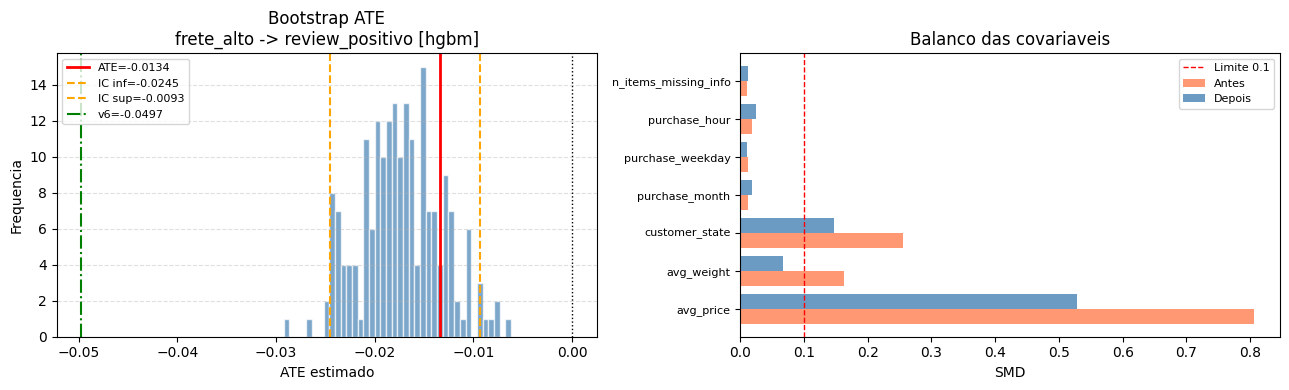

In [7]:
r2 = run_iptw_analysis(
    df, "frete_alto", "review_positivo",
    confundidores=CONF_FRETE,
    model="hgbm",
    trim_percentile=99,
    n_bootstrap=200,
    ate_v6=-0.049713,
    assoc_bruta=-0.0051
)

## 6. pedido_grande — corrigido

### 6.1 — Pedido grande -> Entrega atrasada

IPTW v7: pedido_grande -> entrega_atrasada  [PS: logistic]
N apos dropna: 96,929

AUC-ROC PS: 0.6540
PS     — media: 0.100 | min: 0.021 | max: 0.990
Pesos  — media: 0.995 | min: 0.101 | max: 1.236

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
total_price              0.2962      0.1795        FAIL
avg_weight               0.0271      0.0094          OK
customer_state           0.0409      0.0019          OK
purchase_month           0.0001      0.0003          OK
purchase_weekday         0.0299      0.0016          OK
purchase_hour            0.0254      0.0032          OK
n_items_missing_info     0.0809      0.0226          OK

ATE (IPTW v7):    -0.015630
ATE (IPTW v6):    -0.016338  (diff: +0.000708)
Assoc. bruta EDA: -0.015700
Calculando IC via bootstrap (200 amostras, logistic)...
IC 95%: [-0.020492, -0.010202]
Resultado: Significativo


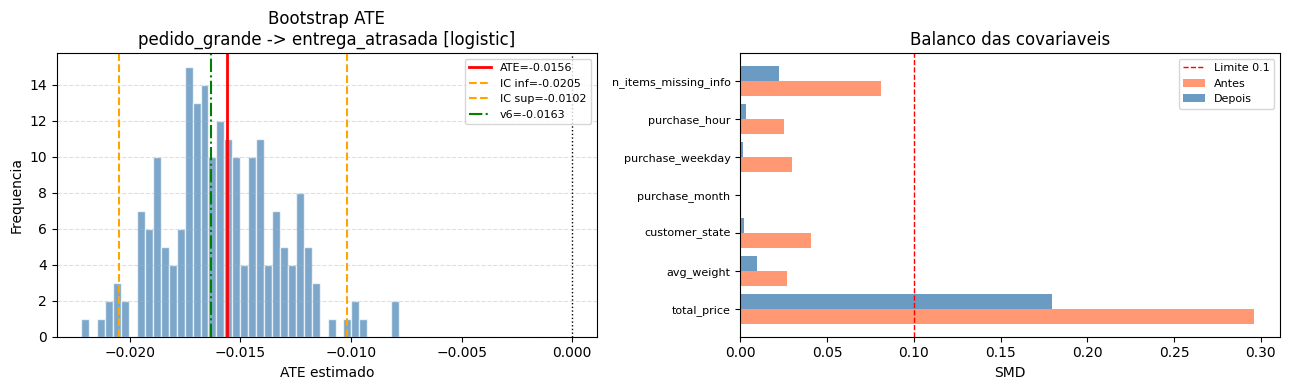

In [8]:
r3 = run_iptw_analysis(
    df, "pedido_grande", "entrega_atrasada",
    confundidores=CONF_PEDIDO,
    model="logistic",
    trim_percentile=99,
    n_bootstrap=200,
    ate_v6=-0.016338,
    assoc_bruta=-0.0157
)

### 6.2 — Pedido grande -> Review positivo

IPTW v7: pedido_grande -> review_positivo  [PS: logistic]
N apos dropna: 96,929

AUC-ROC PS: 0.6540
PS     — media: 0.100 | min: 0.021 | max: 0.990
Pesos  — media: 0.995 | min: 0.101 | max: 1.236

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
total_price              0.2962      0.1795        FAIL
avg_weight               0.0271      0.0094          OK
customer_state           0.0409      0.0019          OK
purchase_month           0.0001      0.0003          OK
purchase_weekday         0.0299      0.0016          OK
purchase_hour            0.0254      0.0032          OK
n_items_missing_info     0.0809      0.0226          OK

ATE (IPTW v7):    -0.167832
ATE (IPTW v6):    -0.169202  (diff: +0.001370)
Assoc. bruta EDA: -0.163300
Calculando IC via bootstrap (200 amostras, logistic)...
IC 95%: [-0.178344, -0.156681]
Resultado: Significativo


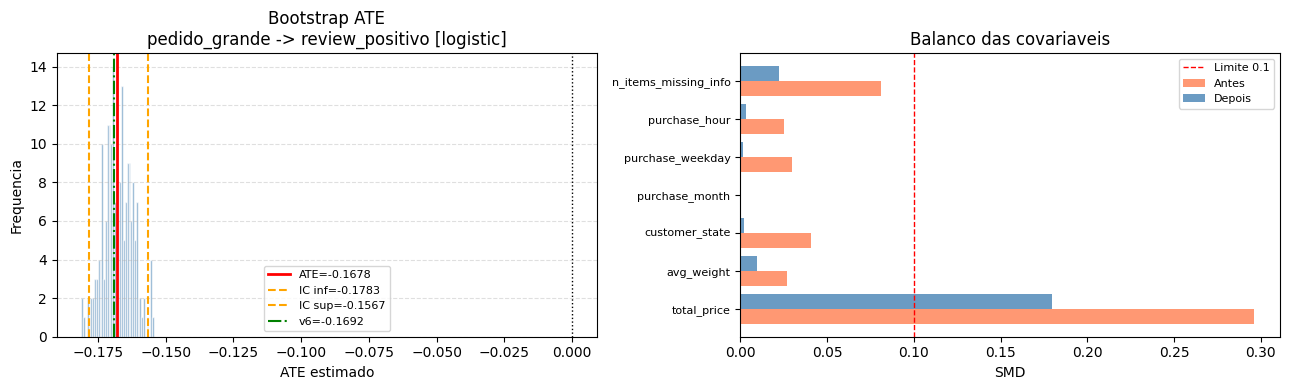

In [9]:
r4 = run_iptw_analysis(
    df, "pedido_grande", "review_positivo",
    confundidores=CONF_PEDIDO,
    model="logistic",
    trim_percentile=99,
    n_bootstrap=200,
    ate_v6=-0.169202,
    assoc_bruta=-0.1633
)

## 7. Comparacao final: Assoc. bruta vs v6 vs v7

In [10]:
resultados = [r1, r2, r3, r4]
df_comp = pd.DataFrame(resultados)

print("Comparacao: Assoc. bruta (EDA) -> ATE v6 -> ATE v7")
print("=" * 85)
print(df_comp[["treatment", "outcome", "model_ps", "auc",
               "assoc_bruta", "ate_v6", "ate",
               "ic_lower", "ic_upper", "significativo"]].to_string(index=False))

Comparacao: Assoc. bruta (EDA) -> ATE v6 -> ATE v7
    treatment          outcome model_ps    auc  assoc_bruta  ate_v6     ate  ic_lower  ic_upper  significativo
   frete_alto entrega_atrasada     hgbm 0.9560       0.0033  0.0135  0.0054    0.0069    0.0172           True
   frete_alto  review_positivo     hgbm 0.9560      -0.0051 -0.0497 -0.0134   -0.0245   -0.0093           True
pedido_grande entrega_atrasada logistic 0.6540      -0.0157 -0.0163 -0.0156   -0.0205   -0.0102           True
pedido_grande  review_positivo logistic 0.6540      -0.1633 -0.1692 -0.1678   -0.1783   -0.1567           True


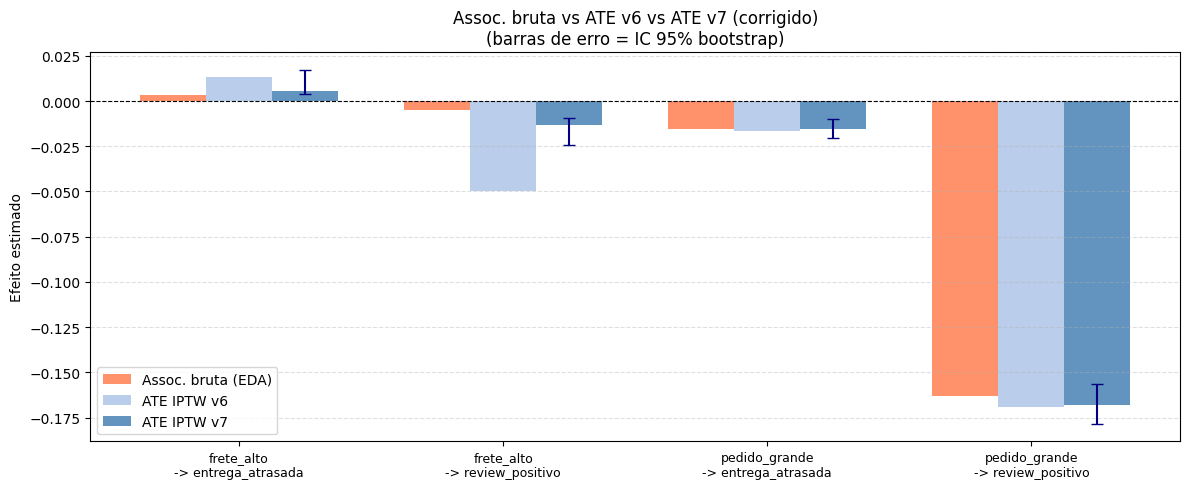

In [12]:
labels = [f"{r['treatment']}\n-> {r['outcome']}" for r in resultados]
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, df_comp["assoc_bruta"], width, label="Assoc. bruta (EDA)", color="coral",       alpha=0.85)
ax.bar(x,         df_comp["ate_v6"],      width, label="ATE IPTW v6",         color="#aec6e8",    alpha=0.85)
ax.bar(x + width, df_comp["ate"],         width, label="ATE IPTW v7",         color="steelblue",  alpha=0.85)

ax.errorbar(x + width, df_comp["ate"],
            yerr=[np.abs(df_comp["ate"] - df_comp["ic_lower"]),
                  np.abs(df_comp["ic_upper"] - df_comp["ate"])],
            fmt="none", color="navy", capsize=4, linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Efeito estimado")
ax.set_title("Assoc. bruta vs ATE v6 vs ATE v7 (corrigido)\n"
             "(barras de erro = IC 95% bootstrap)", fontsize=12)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../../reports/figures/iptw_v7_comparacao_final.png", dpi=150)
plt.show()


# Análise dos Resultados — Notebook v7

---

## frete_alto — ainda problemático

- **AUC-ROC = 0.956** → sinal crítico  
  - Um bom propensity score deveria ter AUC entre **0.6 e 0.8**  
  - Aqui, o modelo praticamente prevê quem recebe tratamento  

Interpretação:
- Grupos tratado vs controle são **muito diferentes**
- Problema de **falta de suporte comum**
- IPTW não consegue balancear corretamente  

---

### Consequências

- `avg_price` ainda desbalanceado (**SMD = 0.53**)  
- `customer_state` desbalanceado (**SMD = 0.15**)  

Causa estrutural:
- `frete_alto = freight / price > 0.2`
- O **preço define o tratamento**

>  Nenhum modelo de propensity score resolve isso enquanto o tratamento for derivado do preço

---

### Inconsistência no intervalo de confiança

- ATE (HGBM) = **+0.0054**  
- IC bootstrap (logístico) = **[0.0069, 0.0172]**

👉 Problema:
- O IC **não contém o ATE pontual**

> Métodos estão estimando coisas diferentes → inferência inválida

---

## pedido_grande — estável e confiável

### Comparação entre versões

| Análise | Assoc. bruta | v6 | v7 | Mudança |
|--------|-------------|----|----|--------|
| pedido_grande → entrega_atrasada | −0.016 | −0.016 | −0.016 | quase zero |
| pedido_grande → review_positivo  | −0.163 | −0.169 | −0.168 | quase zero |

---

### Interpretação

- Alta estabilidade entre versões → efeito **robusto**
- `total_price` ainda com SMD = 0.18 (**não ideal**)
- **AUC = 0.654** → dentro do aceitável
- Pesos estáveis (**max = 1.236**)

Conclusão:
- Resultado **confiável**, apesar de pequeno desbalanceamento residual  

---

## Tabela resumo final — todos os notebooks

| Análise | Assoc. bruta | ATE v6 | ATE v7 | Confiável? |
|--------|-------------|--------|--------|------------|
| despacho_lento → entrega_atrasada  | +0.079 | +0.079 | —      | ✅ v6 ok |
| despacho_lento → review_positivo   | −0.086 | −0.088 | —      | ✅ v6 ok |
| aprovacao_lenta → entrega_atrasada | +0.016 | +0.016 | —      | ✅ v6 ok |
| aprovacao_lenta → review_positivo  | −0.016 | −0.010 | —      | ✅ v6 ok |
| pedido_grande → entrega_atrasada   | −0.016 | −0.016 | −0.016 | ✅ estável |
| pedido_grande → review_positivo    | −0.163 | −0.169 | −0.168 | ✅ estável |
| frete_alto → entrega_atrasada      | +0.003 | +0.014 | +0.005 | ⚠️ IC inválido |
| frete_alto → review_positivo       | −0.005 | −0.050 | −0.013 | ⚠️ AUC=0.96 |

---

## Diagnóstico final — frete_alto

O problema **não é o modelo**, é o desenho do tratamento

- `frete_alto = total_freight / total_price > 0.2`

### Problema estrutural:
- Combina duas variáveis na mesma métrica
- Cria dependência direta com `total_price`

 Consequência:
- Não é possível separar:
  - efeito do frete  
  - efeito do preço  

> IPTW não consegue identificar efeito causal válido nesse cenário